# Block 2 — Advanced structural and tensor analysis with `apsg`

*Modern Workflow in Geology, 8 October 2026 — IPSG, Charles University*

Things that take hours by hand and seconds in code:

| Section | Topic |
|---|---|
| 2.1 | Fault-slip data |
| 2.2 | Kinematic analysis: P/T axes and right dihedra |
| 2.3 | Deformation gradient and strain ellipsoid |
| 2.4 | Progressive deformation |
| 2.5 | Case study: transpression |
| 2.6 | Superposition of deformations |
| 2.7 | Strain analysis: Rf/φ and mean strain ellipsoid |
| 2.8 | Stress tensor |
| 2.9 | Stress inversion from fault data |
| 2.10 | Hands-on exercise |

**Convention reminder:** tensors are combined with `@` (matrix product) — never `*`.

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from apsg import *
from apsg.pandas import pd

DATA = Path("data")
OUT = Path("output")
OUT.mkdir(exist_ok=True)
np.random.seed(2026)                   # reproducible random examples

## 2.1 Fault-slip data

A `fault` is a plane + striation + **sense of movement**. `data/mele.csv` holds 94
measured faults with columns `fazi, finc` (plane, dip direction/dip), `lazi, linc`
(striation, trend/plunge) and `sense` (`1` normal, `-1` reverse).

In [ ]:
pd.read_csv(DATA / "mele.csv").head()

In [ ]:
faults = faultset.from_csv(DATA / "mele.csv", name = "Mele")      # or: pd.read_csv(...).fault()
faults, faults[:3]

Single faults can be typed in any way that is convenient — with the sense as a number or
a letter (`n`, `r`, `s` sinistral, `d` dextral):

In [ ]:
print(fault(140, 30, 110, 26, "r"))
print(fault(fol(120, 80), lin(32, 10), "s"))

Two standard plots: **Angelier** (great circle + striation arrow showing the hanging-wall
movement) and **Hoeppner** (pole of the plane + arrow).

In [ ]:
s = StereoNet(title="Angelier plot")
s.fault(faults)
s.show()

In [ ]:
s = StereoNet(title="Hoeppner plot")
s.hoeppner(faults)
s.show()

## 2.2 Kinematic analysis: P/T axes and right dihedra

Every fault defines a **P** (shortening) and **T** (extension) axis at 45° to the plane in
the movement plane. Their distributions give a first, model-free picture of the
kinematics.

In [ ]:
P, T = faults.p, faults.t          # LineationSets
s = StereoNet(title="P and T axes")
s.contour(P, levels=5, cmap="Reds", alpha=0.6)
s.line(P, color="r", ms=3, label="P")
s.line(T, color="b", ms=3, label="T")
s.show()
print("mean P:", P.ortensor().eigenlins(0), "   mean T:", T.ortensor().eigenlins(0))

The **right-dihedra method** (Angelier & Mechler 1977) uses only the geometry of each
fault: the fault plane and the auxiliary plane (normal to the slip) split the sphere
into two compressional and two extensional dihedra. σ1 must lie in the compressional and
σ3 in the extensional pair. `s.dihedra()` shades the extensional dihedra (the
quadrants that contain the T axis):

In [ ]:
f = faults[62]
s = StereoNet(title=f"Fault {f}: extensional dihedra")
s.dihedra(f)
s.fault(f)
s.line(f.p, color="r", label="P")
s.line(f.t, color="b", label="T")
s.show()

For a `FaultSet` the shaded dihedra add up. Directions that most faults place in the
extensional dihedra appear darkest, and σ3 is likely there. The unshaded directions are
the σ1 candidates (for clarity just first 10 faults is plotted):

In [ ]:
s = StereoNet(title=f"Right dihedra: {len(faults)} faults overlaid")
s.dihedra(faults[:10])
s.line(P[:10].ortensor().eigenlins(0), color="r", ms=10, label="mean P")
s.line(T[:10].ortensor().eigenlins(0), color="b", ms=10, label="mean T")
s.show()

`StereoGrid.angmech()` turns the same idea into numbers. For every direction it counts
how many faults place it in their compressional (+) or extensional (–) dihedron; the
maximum is the most likely σ1 direction.

In [ ]:
g = StereoGrid()
g.angmech(faults)
s = StereoNet(title="Right dihedra (count)")
s.contour(g, clip=False, colorbar=True)
s.show()
print(g)          # reports where the maximum (sigma1) and minimum (sigma3) lie

## 2.3 Deformation gradient and strain ellipsoid

`defgrad` is the deformation gradient **F** — it maps undeformed to deformed vectors. It
can be written out or built from components / ratios.

In [ ]:
F = defgrad.from_comp(xx=2, zz=0.5, xz=1)   # stretching along x + simple-shear component
F

In [ ]:
print("deformed x axis:", F @ vec("x"))
print("rotation part R:\n", F.R)
print("stretch part U:\n", F.U)

Any feature or set can be transformed. Planes transform correctly as planes (through
their poles with the inverse transpose) — no manual bookkeeping:

In [ ]:
Lrand = linset.gss(n=300)   # nearly random lines
s = StereoNet(title="Random lines before (grey) and after F")
s.line(Lrand, color="0.7", ms=2)
s.line(Lrand.transform(F), color="k", ms=3)
s.show()

The **finite strain ellipsoid** (Finger tensor B = F·Fᵀ) gives axial ratios, the Flinn
`k` value and the principal directions.

In [ ]:
B = ellipsoid.from_defgrad(F)
print(B)
print(f"Rxy={B.Rxy:.2f}  Ryz={B.Ryz:.2f}  k={B.k:.2f}  lode={B.lode:.2f}")
print("principal axes:", B.eigenlins())

The ellipsoid stores only the **stretch**: `B.defgrad()` returns the symmetric left
stretch **V** (= `F.V`), and **F = V·R**. The rotation part **R** cannot be recovered from
a measured strain ellipsoid.

In [ ]:
V = B.defgrad()                  # symmetric stretch, the same as F.V
print(V)
print("V @ R == F:", np.allclose(V @ F.R, F))

In [ ]:
print(defgrad.from_ratios(Rxy=2, Ryz=3))        # coaxial F from axial ratios

## 2.4 Progressive deformation

A **velocity gradient** `velgrad` **L** describes the *instantaneous* flow. Integrating it
over time gives the finite deformation **F = exp(L t)**.

In [ ]:
Lps = velgrad.from_comp(xx=-1, zz=1)            # pure shear
Lss = velgrad.from_comp(xz=1)                   # simple shear
Lgs = velgrad.from_comp(xx=-0.5, zz=0.5, xz=1)  # general shear
for name, L in [("pure", Lps), ("simple", Lss), ("general", Lgs)]:
    print(f"{name:8s} kinematic vorticity Wk = {L.kinematic_vorticity:.2f}")

Vorticity controls *rotation*; the *shape* of the strain ellipsoid is set by the
stretching rates. Coaxial flows with different symmetry trace different paths in the
Flinn diagram:

In [ ]:
flows = {"constriction": velgrad.from_comp(xx=1, yy=-0.5, zz=-0.5),
         "plane strain": velgrad.from_comp(xx=1, zz=-1),
         "flattening":   velgrad.from_comp(xx=0.5, yy=0.5, zz=-1)}
times = np.linspace(0, 1, 25)

fp = FlinnPlot(title="Strain paths")
for name, L in flows.items():
    fp.path(ellipsoidset([ellipsoid.from_defgrad(L.defgrad(time=t)) for t in times]),
            label=name, marker=".")
fp.show()

The same integrated tensors rotate fabrics. A lineation cluster followed through time:

In [ ]:
L0 = linset.random_fisher(position=lin(245, 50), kappa=50, n=50)
s = StereoNet(title="Lineations during simple shear (x = 0/0, shear plane = horizontal)")
for t, c in zip([0, 0.5, 1, 2, 4], ["0.8", "0.6", "0.4", "0.2", "k"]):
    s.line(L0.transform(Lss.defgrad(time=t)), color=c, ms=2+t/2, label=f"t = {t}")
s.show()

## 2.5 Case study: transpression

**Transpression** combines strike-slip (wrench) motion with shortening across a zone
(Sanderson & Marchini, 1984). The zone is decoupled from the rigid blocks on either side
(free-slip boundaries). Volume is preserved because shortening across the zone is balanced
by vertical extrusion.

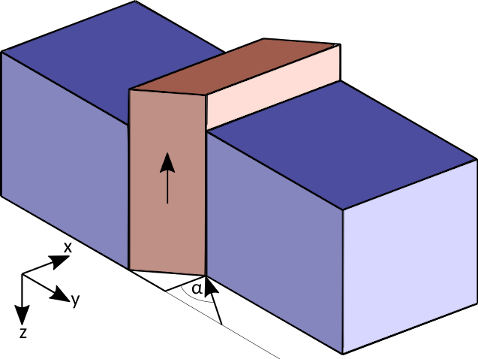

Here x runs along the zone, y across it and z down, which is the apsg frame (x = north,
z = down). Convergence at angle **α** to the zone boundary splits the bulk strain rate
$\dot\varepsilon_0$ into a simple-shear component $\dot\gamma = \dot\varepsilon_0\cos\alpha$
and a pure-shear component $\dot\varepsilon = \dot\varepsilon_0\sin\alpha$:

$$ \mathbf{L} = \begin{bmatrix} 0 & \dot\gamma & 0 \\ 0 & -\dot\varepsilon & 0 \\ 0 & 0 & \dot\varepsilon \end{bmatrix} $$

With a natural strain rate of $3\cdot10^{-15}\,\mathrm{s^{-1}}$ and 0–10 Ma of deformation,
we look at how the shape and orientation of the finite strain ellipsoid depend on α and time.

In [ ]:
Ma = 1e6 * 365.25 * 24 * 3600          # seconds in 1 Ma
sr = 3e-15                              # bulk strain rate (1/s)

def transpression(alpha, sr=sr):
    """Velocity gradient of Sanderson & Marchini (1984) transpression."""
    a = np.radians(alpha)
    return velgrad.from_comp(xy=sr * np.cos(a), yy=-sr * np.sin(a), zz=sr * np.sin(a))

One example: convergence at α = 30° for 5 Ma. `L.defgrad(time=...)` integrates the flow (F = exp(L t)):

In [ ]:
Ltp = transpression(30)
E = ellipsoid.from_defgrad(Ltp.defgrad(time=5 * Ma))
print(f"Wk = {Ltp.kinematic_vorticity:.2f}")
print(f"Rxy={E.Rxy:.2f}  Ryz={E.Ryz:.2f}  k={E.k:.2f}  d={E.d:.2f}")
print("X, Y, Z:", E.eigenlins())

**Strain paths** in the Flinn diagram. Pure wrenching (α = 0°, simple shear) and pure
shortening (α = 90°, pure shear) are both plane strain (k = 1). Every oblique convergence
produces flattening (k < 1):

In [ ]:
ages = np.linspace(0, 10, 21)            # Ma

fp = FlinnPlot(title="Transpression strain paths, 0-10 Ma")
for alpha in [0, 15, 30, 45, 60, 90]:
    Ltp = transpression(alpha)
    fp.path(ellipsoidset([ellipsoid.from_defgrad(Ltp.defgrad(time=t * Ma)) for t in ages]),
            label=f"α = {alpha}°", marker=".")
fp.show()

The full picture: Flinn **k** (symmetry) and **d** (intensity) for every combination of
convergence angle and duration. The X direction is stored at the same time for the next
step.

In [ ]:
alphas = np.linspace(0, 90, 46)
durations = np.linspace(0.01, 10, 40)     # Ma
k = np.zeros((len(alphas), len(durations)))
d = np.zeros_like(k)
Xplunge = np.zeros_like(k)
for i, alpha in enumerate(alphas):
    Ltp = transpression(alpha)
    for j, t in enumerate(durations):
        E = ellipsoid.from_defgrad(Ltp.defgrad(time=t * Ma))
        k[i, j], d[i, j] = E.k, E.d
        Xplunge[i, j] = E.eigenlins()[0].geo[1]

fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.contourf(durations, alphas, d, 15)
fig.colorbar(cf, ax=ax, label="Flinn d (intensity)")
kc = ax.contour(durations, alphas, k, [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9], colors="w")
ax.clabel(kc, fontsize=8)
ax.set(xlabel="duration (Ma)", ylabel="convergence angle α (°)",
       title="Transpression: intensity d (colour) and symmetry k (lines)")
plt.show()

k is lowest at α ≈ 20°, which is where the **X and Y axes swap**. L has no vertical shear, so
the principal axes are always horizontal or vertical, and a table describes them better than
a stereonet. In wrench-dominated transpression X is horizontal and oblique to the zone, and it
rotates towards the zone boundary (x = 0°/180°) with time. Once the pure-shear component
dominates, X becomes vertical and the horizontal Y axis takes over the oblique trend:

In [ ]:
switch = alphas[(Xplunge > 45).any(axis=1)].min()
print(f"X turns vertical for α >= {switch:.0f}° (within 0-10 Ma)\n")

for alpha in [10, 15, 19, 30]:
    Ltp = transpression(alpha)
    X = [ellipsoid.from_defgrad(Ltp.defgrad(time=t * Ma)).eigenlins()[0] for t in [1, 5, 10]]
    print(f"α = {alpha:2d}°   X at 1, 5, 10 Ma:", *X)

## 2.6 Superposition of deformations

Finite deformations combine by **matrix multiplication**; the later deformation is on
the left: **F = F₂ · F₁**. Matrix multiplication is not commutative, so the *order of
events matters*.

In [ ]:
F1 = defgrad.from_comp(xx=2, zz=0.5)                     # D1: pure shear
F2 = rotation.from_axisangle(lin(0, 90), 60)             # rigid rotation around vertical
F3 = defgrad.from_comp(xy=1)                             # D2: simple shear

A = F3 @ F2 @ F1          # D1, then rotation, then D2
Bord = F1 @ F2 @ F3       # reverse order
for name, F in [("D1 -> rot -> D2", A), ("D2 -> rot -> D1", Bord)]:
    E = ellipsoid.from_defgrad(F)
    print(f"{name}:  Rxy={E.Rxy:.2f} Ryz={E.Ryz:.2f}  X={E.eigenlins()[0]}")

## 2.7 Strain analysis: Rf/φ and mean strain ellipsoid

Real strain markers (pebbles, ooids, reduction spots) were never perfect circles. After
deformation each marker shows a final axial ratio **Rf** and orientation **φ** that mix
the tectonic strain with its initial shape. The **Rf/φ method** separates them
statistically: `EllipseSet.rfphi()` takes the vector mean of ln(Rf) in doubled-angle
space and returns the tectonic strain ellipse (**Rs**, **φs**).

A synthetic test first — 80 randomly oriented elliptical pebbles (initial ratio 1–2.5)
deformed by a simple shear with γ = 1.5:

In [ ]:
rng = np.random.default_rng(42)       # own generator, keeps the global seed for later cells
Ri = np.exp(rng.uniform(0, np.log(2.5), 80))         # initial axial ratios
phi_i = rng.uniform(0, 180, 80)                       # random initial orientations
pebbles0 = ellipseset([ellipse.from_ratio(R=r).transform(rotation2.from_angle(p))
                       for r, p in zip(Ri, phi_i)], name="initial")

F = defgrad2.from_comp(xy=1.5)                        # simple shear, gamma = 1.5
pebbles = pebbles0.transform(F)
Etrue = ellipse.from_defgrad(F)
pebbles, Etrue

In [ ]:
Ers = pebbles.rfphi()
wrap = lambda a: (a + 90) % 180 - 90                  # phi in -90..90

fig, ax = plt.subplots()
ax.scatter(wrap(pebbles0.orientation), pebbles0.ar, s=12, c="0.7", label="initial")
ax.scatter(wrap(pebbles.orientation), pebbles.ar, s=12, c="k", label="deformed")
ax.scatter(wrap(Ers.orientation), Ers.ar, s=250, c="r", marker="*", label="Rs, φs")
ax.set(xlim=(-90, 90), ylim=(1, None), xlabel="φ (deg)", ylabel="Rf", title="Rf/φ plot")
ax.legend()
plt.show()

`EllipseSet.robin()` computes the mean in a different way — the log-matrix mean of
Robin (1977): average the matrix logarithms of the tensors and take the exponential.
For area-preserving markers in 2D it is the same calculation written with tensors, so
both estimates agree. They come out slightly above the true value, because the initial
ellipticity of the markers is not completely averaged out — a known limitation of the
vector mean. The simple arithmetic mean of Rf is much worse:

In [ ]:
Erb = pebbles.robin()
print(f"true      Rs = {Etrue.ar:.2f}  phi = {Etrue.orientation:.1f}")
print(f"rfphi()   Rs = {Ers.ar:.2f}  phi = {Ers.orientation:.1f}")
print(f"robin()   Rs = {Erb.ar:.2f}  phi = {Erb.orientation:.1f}")
print(f"mean(Rf)  Rs = {pebbles.ar.mean():.2f}")

The log-matrix mean works in 3D as well. `EllipsoidSet.robin()` averages strain
ellipsoids from several stations — for example from Fry analysis or three-section
measurements across an outcrop — into one mean strain ellipsoid. It keeps the unit
volume of the stations; a plain average of the tensor components does not, so it is
not a valid strain ellipsoid of the same deformation.

In [ ]:
stations = ellipsoidset([
    ellipsoid.from_ratios(Rxy=rng.uniform(2, 3), Ryz=rng.uniform(1.2, 1.8))
             .transform(rotation.from_axisangle(lin(rng.uniform(0, 360), rng.uniform(0, 90)),
                                                rng.normal(0, 15)))
    for _ in range(15)], name="stations")       # X ~ N-S, Z ~ vertical, scattered by ~15 deg

Emean = stations.robin()
Earith = ellipsoid(np.mean([np.asarray(E) for E in stations], axis=0))
for name, E in [("robin()", Emean), ("arithmetic", Earith)]:
    print(f"{name:10s} Rxy={E.Rxy:.2f} Ryz={E.Ryz:.2f} k={E.k:.2f} "
          f"volume={np.sqrt(np.linalg.det(E)):.2f}  X, Y, Z: {E.eigenlins()}")

In [ ]:
fp = FlinnPlot(title="Station ellipsoids and their Robin mean")
fp.point(stations, color="0.5", label="stations")
fp.point(Emean, color="r", ms=10, label="Robin mean")
fp.show()

s = StereoNet(title="Principal axes X (red), Y (green), Z (blue)")
s.tensor(stations, planes=False, ms=4, alpha=0.5)   # axes of all stations
s.tensor(Emean, planes=False, ms=12, mec="k")       # Robin mean
s.show()

## 2.8 Stress tensor

`stress` uses the geological sign convention (**compression positive**), so `sigma1` is
the most compressive principal stress.

In [ ]:
S = stress.from_comp(xx=8, yy=5, zz=1)          # sigma1 N-S horizontal, sigma3 vertical
print("principal stresses:", S.sigma1, S.sigma2, S.sigma3)
print("sigma1 / sigma3   :", lin(S.sigma1dir), lin(S.sigma3dir))
print("shape ratio R     :", round(S.shape_ratio, 3))

On any plane we can resolve the traction into normal and shear components — and ask
which way a fault on that plane would slip (Wallace–Bott hypothesis: parallel to the
maximum resolved shear stress).

In [ ]:
n = fol(120, 60)
print(f"normal stress  = {S.normal_stress(n):.2f}")
print(f"shear stress   = {S.shear_stress(n):.2f}")
print(f"slip tendency  = {S.slip_tendency(n):.2f}")
print("predicted fault:", S.fault(n))

**Slip tendency** $T_s = \tau / \sigma_n$ (Morris et al., 1996) is the ratio of the shear stress to the
normal stress resolved on a plane. A plane slips when $T_s$ reaches its friction coefficient μ.
For most rocks μ ≈ 0.6–0.85 (Byerlee's law). $T_s$ therefore ranks planes of every orientation
by how close they are to reactivation in a given stress field:

- **high $T_s$**: planes at ~20–30° to σ1 that contain σ2. These are the favourably oriented
  faults, which slip first.
- **low $T_s$**: planes perpendicular to σ1 (high normal, no shear stress) or parallel to a
  principal stress.

`S.slip_tendency(n, fp=...)` also takes a fluid pressure: it lowers the effective normal stress
and raises $T_s$ on all planes. For the map we rotate `S` so that no principal axis lies on a
coordinate axis (same magnitudes, oblique orientation, as in nature). We then evaluate $T_s$
for every pole direction on a `StereoGrid` and contour it. Each point is the **pole** of a
plane, so the maxima lie ~70° from σ1 and ~90° from σ2.

In [ ]:
rot = rotation.from_axisangle(lin(120, 50), 40)
Sr = S.transform(rot)                   # same magnitudes, oblique axes
print("sigma1, sigma2, sigma3:", lin(Sr.sigma1dir), lin(Sr.sigma2dir), lin(Sr.sigma3dir))

g = StereoGrid()
g.apply_func(Sr.slip_tendency)          # evaluate a function for every pole direction
print(g)
s = StereoNet(title="Slip tendency (poles of planes)")
s.contour(g, colorbar=True)
s.stress(Sr)
s.show()

## 2.9 Stress inversion from fault data

`faultset.stress_inversion()` implements the linear least-squares method of Michael
(1984): it finds the reduced stress tensor that best explains all striations at once.

**First, a test on synthetic data** — faults generated from a known tensor must give the
tensor back:

In [ ]:
synthetic = faultset([S.fault(n) for n in vecset.gss(n=200)])
Sinv = synthetic.stress_inversion()
print("true     sigma1:", lin(S.sigma1dir), " R =", round(S.shape_ratio, 2))
print("inverted sigma1:", lin(Sinv.sigma1dir), " R =", round(Sinv.shape_ratio, 2))

**Now the real data:**

In [ ]:
Smele = faults.stress_inversion()
print("sigma1:", lin(Smele.sigma1dir))
print("sigma2:", lin(Smele.sigma2dir))
print("sigma3:", lin(Smele.sigma3dir))
print("R     :", round(Smele.shape_ratio, 2))

The **misfit** is the angle between the measured striation and the slip predicted by the
tensor on each plane. Large misfits flag faults that belong to another event (or bad
measurements).

In [ ]:
misfit = faults.angular_misfit(Smele)
print(f"median misfit {np.median(misfit):.1f} deg, {np.mean(misfit < 30):.0%} of faults < 30 deg")
plt.hist(misfit, bins=18, range=(0, 180))
plt.xlabel("angular misfit (deg)"); plt.ylabel("faults")
plt.show()

**Uncertainty** by bootstrap: repeat the inversion on resampled data sets.
`bootstrap=True` returns a `Stress3Set`, and `s.tensor()` draws the principal axes of all its
members at once:

In [ ]:
boot = faults.stress_inversion(bootstrap=True, n=100)   # a Stress3Set
s = StereoNet(title="Stress inversion - Mele faults")
s.hoeppner(faults, color="0.6")
s.tensor(boot, planes=False, ms=2, alpha=0.4)   # sigma1/2/3 clouds, one legend entry each
s.stress(Smele, mec="k")
s.show()

## 2.10 Hands-on exercise

**A. Progressive deformation and superposition**

1. Create a cluster of 50 lineations around `lin(90, 20)`.
2. Deform it by D1 = pure shear `velgrad.from_comp(xx=-1, zz=1)` for `time=0.5`, then by
   D2 = simple shear `velgrad.from_comp(xy=1)` for `time=1`.
3. Plot the original, D1 and D1+D2 lineations in one stereonet, and the ellipsoid of
   the total deformation. Does swapping the order change the result?

**B. Brittle structures**

4. Keep only the Mele faults with misfit < 30° and invert again. How much do σ1, σ3 and R
   change?
5. Save a figure with the Angelier plot of the retained faults and the principal
   stresses as PDF.

In [ ]:
# your code here

In [ ]:
# your code here

<details>
<summary><b>Click here to see the solution A</b></summary>

```python
L0 = linset.random_fisher(position=lin(90, 20), kappa=40, n=50)
D1 = velgrad.from_comp(xx=-1, zz=1).defgrad(time=0.5)
D2 = velgrad.from_comp(xy=1).defgrad(time=1)

s = StereoNet(title="D1 then D2")
s.line(L0, color="0.7", ms=3, label="initial")
s.line(L0.transform(D1), color="b", ms=3, label="after D1")
s.line(L0.transform(D2 @ D1), color="r", ms=3, label="after D1 + D2")
s.show()
for name, F in [("D2 @ D1", D2 @ D1), ("D1 @ D2", D1 @ D2)]:
    E = ellipsoid.from_defgrad(F)
    print(f"{name}: Rxy={E.Rxy:.2f} Ryz={E.Ryz:.2f} k={E.k:.2f} X={E.eigenlins()[0]}")
```
</details>

<details>
<summary><b>Click here to see the solution B</b></summary>

```python
good = faultset([f for f, m in zip(faults, misfit) if m < 30], name="Mele, misfit < 30")
Sgood = good.stress_inversion()
print(f"{len(good)} of {len(faults)} faults kept")
for k in (1, 2, 3):
    a, b = lin(getattr(Smele, f"sigma{k}dir")), lin(getattr(Sgood, f"sigma{k}dir"))
    print(f"sigma{k}: all {a}  filtered {b}  (angle {a.angle(b):.1f} deg)")
print(f"R: all {Smele.shape_ratio:.2f}  filtered {Sgood.shape_ratio:.2f}")

s = StereoNet(title=good.name)
s.fault(good)
s.stress(Sgood)
s.savefig(OUT / "mele_filtered.pdf")
s.show()
```
</details>

## Recap

| Task | Code |
|---|---|
| Fault data | `faultset.from_csv(...)`, `df.fault()`, `fault(..., "n")` |
| Fault plots | `s.fault(fs)` (Angelier), `s.hoeppner(fs)` |
| Kinematics | `fs.p`, `fs.t`, `s.dihedra(fs)`, `StereoGrid().angmech(fs)` |
| Finite strain | `defgrad`, `F.R`, `F.U`, `ellipsoid.from_defgrad(F)`, `FlinnPlot` |
| Flow | `velgrad`, `L.defgrad(time=t)`, `L.kinematic_vorticity` |
| Superposition | `F2 @ F1` (later on the left) |
| Strain markers | `ellipseset(...).rfphi()`, `.robin()`, `ellipsoidset(...).robin()` |
| Stress | `stress.from_comp`, `.sigma1dir`, `.shape_ratio`, `.shear_stress(n)`, `.fault(n)` |
| Inversion | `fs.stress_inversion()`, `fs.angular_misfit(S)`, `bootstrap=True` |